<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week4/Day5/Mini_Project_W4_D5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini-Project :** Data Analysis for Marketing Strategy

1. Load and Preprocess the Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load file
df = pd.read_excel("US_Superstore_data.xls")

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Fix decimal separator (might not be necessary with read_excel, but keeping for robustness if formats vary)
df['Sales'] = (
    df['Sales']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df['Profit'] = (
    df['Profit']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Verify
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


2. Which States Have the Most Sales?

In [3]:
state_sales = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(state_sales.head(10))

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


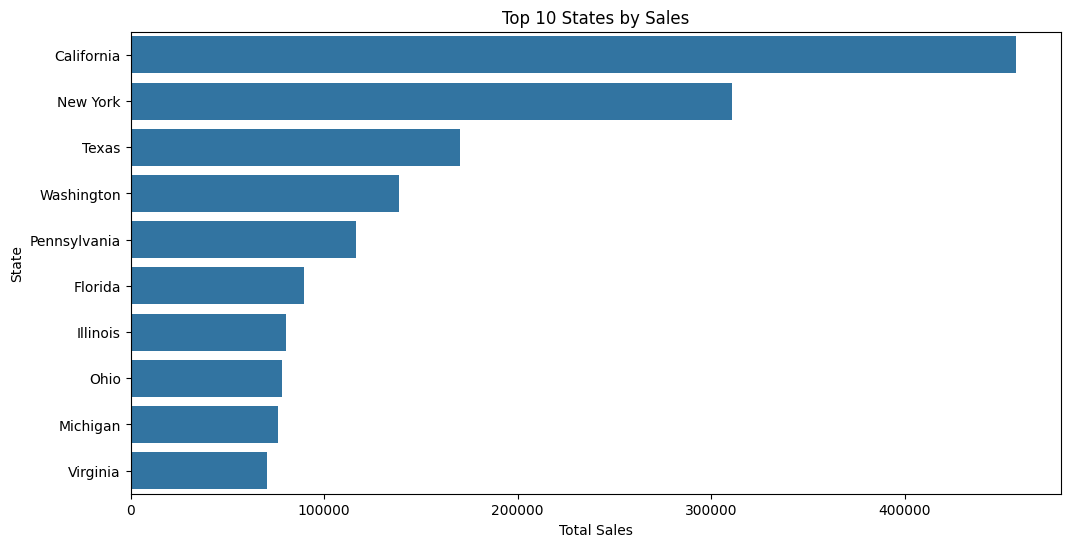

In [4]:
#Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_sales.head(10).values,
    y=state_sales.head(10).index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.show()

3. New York vs California (Sales and Profit)

In [5]:
comparison = (
    df[df['State'].isin(['New York','California'])]
    .groupby('State')[['Sales','Profit']]
    .sum()
)

print(comparison)

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


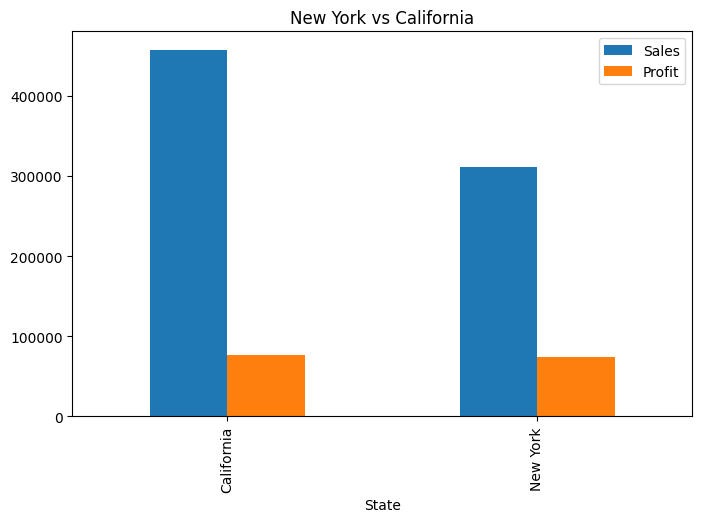

In [6]:
#Visualization
comparison.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("New York vs California")
plt.show()

In [7]:
#Profit Margin
comparison['Profit Margin %'] = (
    comparison['Profit'] /
    comparison['Sales']
) * 100

comparison

,Sales,Profit,Profit Margin %
State,,,
California,457687.6315,76381.3871,16.688541
New York,310876.2710,74038.5486,23.816082


4. Outstanding Customer in New York

In [8]:
ny_customers = (
    df[df['State']=='New York']
    .groupby('Customer Name')
    .agg({
        'Sales':'sum',
        'Profit':'sum'
    })
    .sort_values('Sales', ascending=False)
)

ny_customers.head(10)

,Sales,Profit
Customer Name,,
Tom Ashbrook,13723.498,4599.2073
Peter Fuller,7678.228,543.2819
Seth Vernon,7359.918,1571.7964
Tom Boeckenhauer,6999.960,2239.9872
Greg Tran,6712.744,774.7935
Todd Sumrall,6492.314,1574.9714
Karen Daniels,6241.282,2283.0463
Keith Dawkins,5854.194,2510.8903
Luke Weiss,5048.186,773.1004


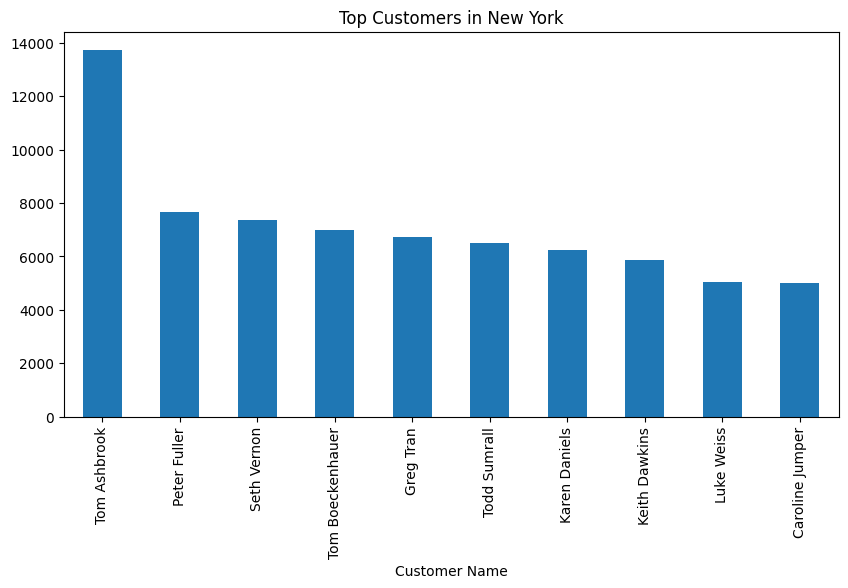

In [9]:
#Visualization
ny_customers['Sales'].head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Customers in New York")
plt.show()

5. Differences Among States in Profitability

In [10]:
#Profitability:
state_profit = (
    df.groupby('State')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

state_profit['Profitability %'] = (
    state_profit['Profit']
    /
    state_profit['Sales']
) * 100

In [11]:
#Top Profitable States
state_profit.sort_values(
    'Profitability %',
    ascending=False
).head(15)

,Sales,Profit,Profitability %
State,,,
District of Columbia,2865.020,1059.5893,36.983662
Delaware,27451.069,9977.3748,36.346034
Minnesota,29863.150,10823.1874,36.242618
Maine,1270.530,454.4862,35.771387
Arkansas,11678.130,4008.6871,34.326447
Indiana,53555.360,18382.9363,34.325110
Georgia,49095.840,16250.0433,33.098615
Montana,5589.352,1833.3285,32.800377
Rhode Island,22627.956,7285.6293,32.197470


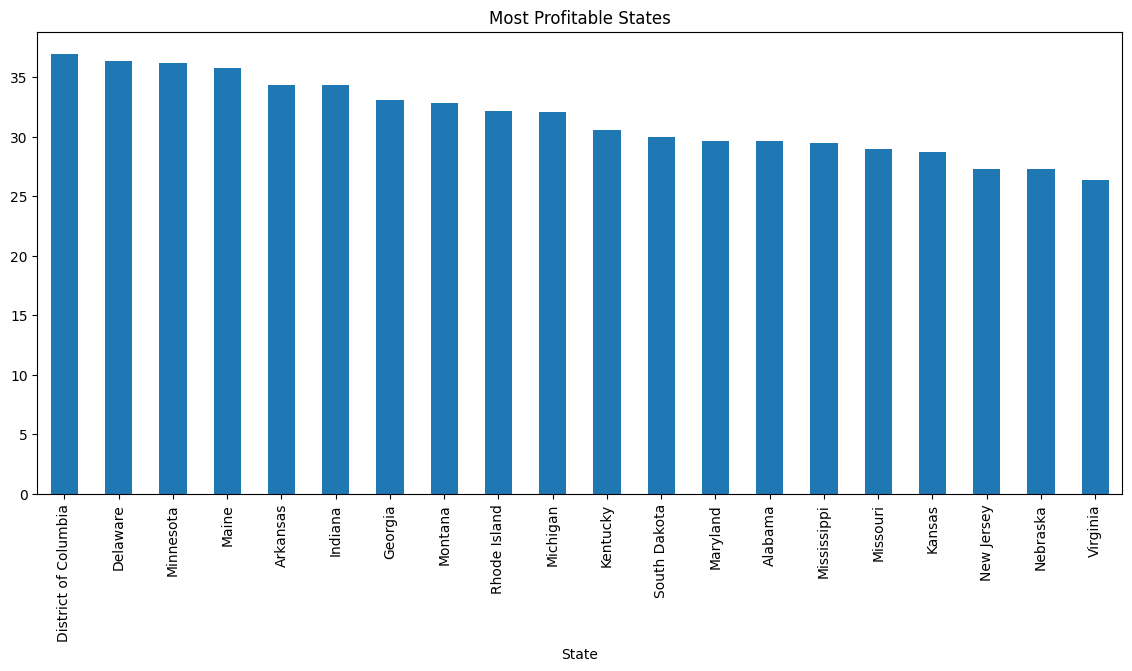

In [12]:
#Visualization
plt.figure(figsize=(14,6))

state_profit['Profitability %'] \
.sort_values(ascending=False) \
.head(20) \
.plot(kind='bar')

plt.title("Most Profitable States")
plt.show()

6. Pareto Principle: Customers and Profit

In [13]:
#Total Profit by Customer
customer_profit = (
    df.groupby('Customer Name')['Profit']
      .sum()
      .sort_values(ascending=False)
)

In [14]:
#Cumulative Profit
pareto_profit = customer_profit.reset_index()

pareto_profit['CumProfit'] = (
    pareto_profit['Profit']
    .cumsum()
)

pareto_profit['CumProfitPct'] = (
    pareto_profit['CumProfit']
    /
    pareto_profit['Profit'].sum()
) * 100

In [15]:
#Check 20%
top20 = int(len(pareto_profit)*0.20)

profit_share = (
    pareto_profit.iloc[:top20]['Profit']
    .sum()
)

profit_pct = (
    profit_share /
    pareto_profit['Profit'].sum()
) * 100

print(f"Top 20% customers contribute {profit_pct:.2f}% of profit")

Top 20% customers contribute 81.43% of profit


7. Top 20 Cities by Sales

In [16]:
city_sales = (
    df.groupby('City')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

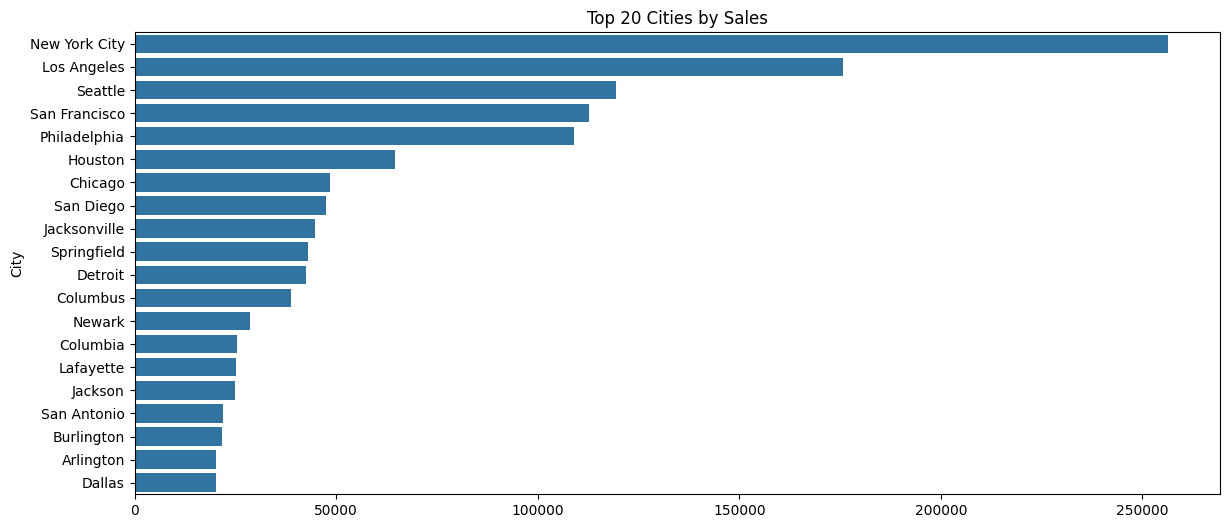

In [17]:
#Visualization
plt.figure(figsize=(14,6))

sns.barplot(
    x=city_sales.values,
    y=city_sales.index
)

plt.title("Top 20 Cities by Sales")
plt.show()

8. Top 20 Cities by Profit

In [18]:
city_profit = (
    df.groupby('City')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

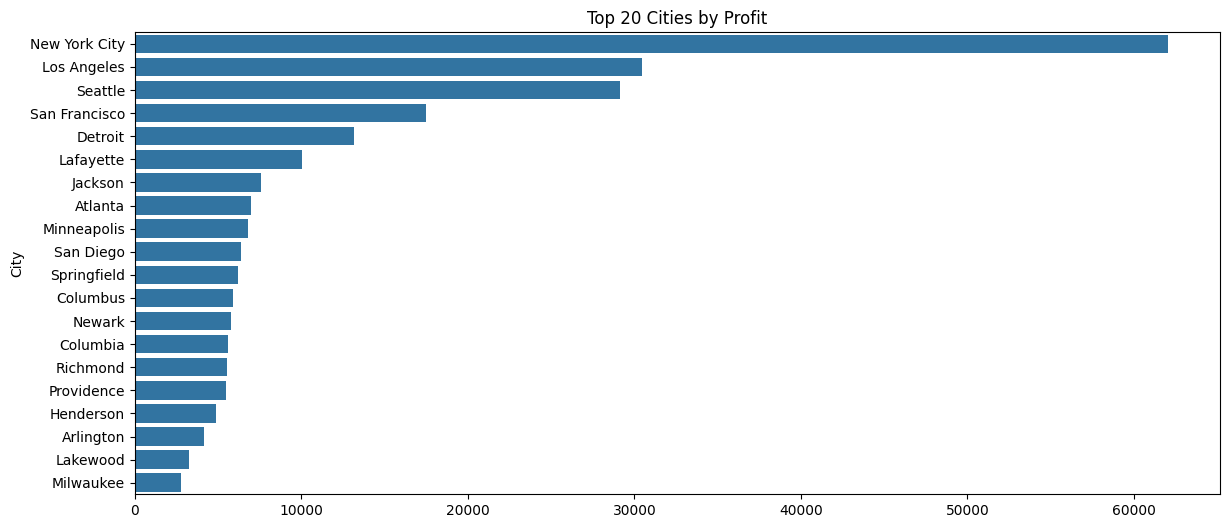

In [19]:
#Visualization
plt.figure(figsize=(14,6))

sns.barplot(
    x=city_profit.values,
    y=city_profit.index
)

plt.title("Top 20 Cities by Profit")
plt.show()

9. City Profitability Analysis

In [20]:
city_analysis = (
    df.groupby('City')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

city_analysis['Profitability %'] = (
    city_analysis['Profit']
    /
    city_analysis['Sales']
) * 100

In [21]:
#Most Profitable Cities
city_analysis.sort_values(
    'Profitability %',
    ascending=False
).head(20)


,Sales,Profit,Profitability %
City,,,
Atlantic City,23.360,11.6800,50.000000
Grand Island,15.960,7.9800,50.000000
New Brunswick,14.770,7.1567,48.454299
Summerville,406.940,196.9132,48.388755
Holland,137.860,66.6588,48.352532
Antioch,19.440,9.3312,48.000000
Davis,32.400,15.5520,48.000000
Royal Oak,35.340,16.9632,48.000000
Lindenhurst,55.480,26.6304,48.000000


In [22]:
#Least Profitable Cities
city_analysis.sort_values(
    'Profitability %'
).head(20)

,Sales,Profit,Profitability %
City,,,
Abilene,1.3920,-3.7584,-270.000000
Mesquite,52.1480,-87.6200,-168.021784
Oswego,321.9780,-536.1276,-166.510631
Romeoville,8.9520,-14.7708,-165.000000
Missouri City,6.3700,-9.5550,-150.000000
Deer Park,6.9240,-10.3860,-150.000000
Littleton,72.2940,-98.8018,-136.666667
Tyler,347.2060,-443.7086,-127.794047
Champaign,151.9600,-182.3520,-120.000000


10. Top 20 Customers by Sales

In [23]:
top_customers = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

top_customers

,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


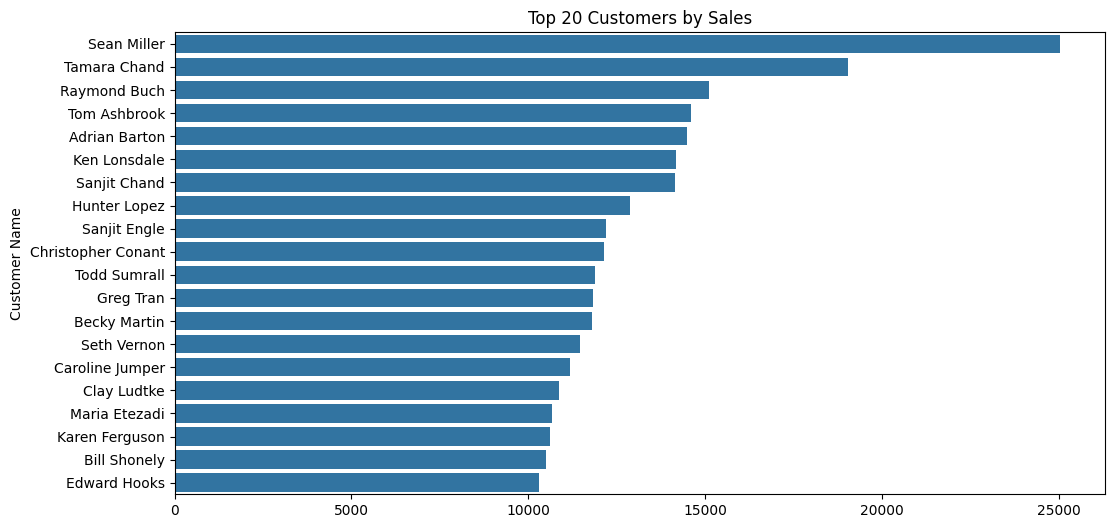

In [24]:
#Visualization
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index
)

plt.title("Top 20 Customers by Sales")
plt.show()

11. Cumulative Sales Curve

In [25]:
customer_sales = (
    df.groupby('Customer Name')['Sales']
      .sum()
      .sort_values(ascending=False)
)

In [26]:
pareto_sales = customer_sales.reset_index()

pareto_sales['CumSales'] = (
    pareto_sales['Sales']
    .cumsum()
)

pareto_sales['CumSalesPct'] = (
    pareto_sales['CumSales']
    /
    pareto_sales['Sales'].sum()
) * 100

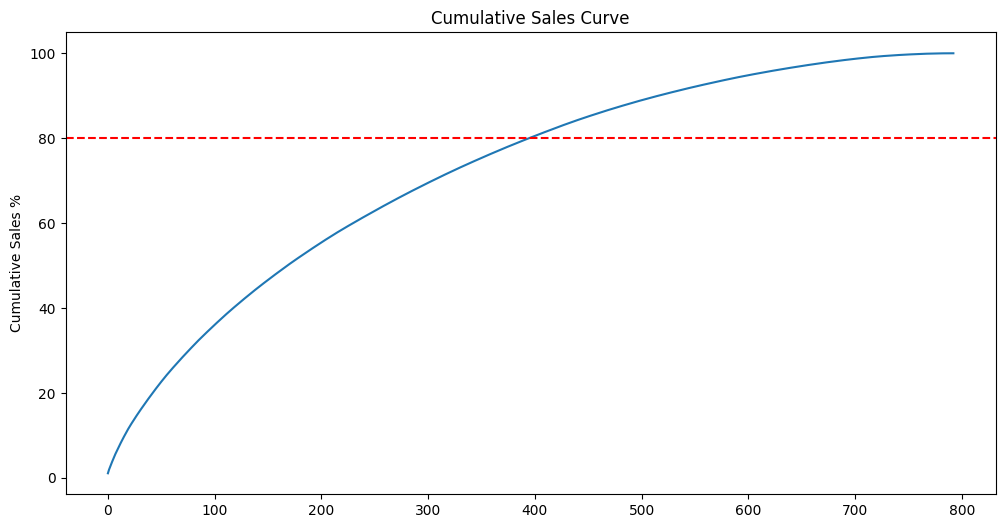

In [27]:
#Plot
plt.figure(figsize=(12,6))

plt.plot(
    pareto_sales['CumSalesPct']
)

plt.axhline(
    y=80,
    color='red',
    linestyle='--'
)

plt.title("Cumulative Sales Curve")
plt.ylabel("Cumulative Sales %")
plt.show()

12. Pareto Principle for Sales

In [28]:
top20 = int(len(pareto_sales)*0.20)

sales_share = (
    pareto_sales.iloc[:top20]['Sales']
    .sum()
)

sales_pct = (
    sales_share /
    pareto_sales['Sales'].sum()
) * 100

print(f"Top 20% customers generate {sales_pct:.2f}% of sales")

Top 20% customers generate 47.96% of sales
